In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from itertools import combinations
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go
import matplotlib.colors as mcolors

In [2]:
## FLY NAMES##
fly_nums=[226,227,228,234,239,240,241,242,249,250]

In [3]:
## PATHS ##

later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
behave_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/behave_all'
if not os.path.exists(behave_dir):
    os.mkdir(behave_dir)


In [4]:
total_path = os.path.join(behave_dir, 'behavior_all.pkl')
redo=False
if os.path.exists(total_path)==False or redo==True:
    print("Making all fly behave dict")
    all_behave_dict = {}

    for x in sorted(os.listdir(behave_dir)):
        if 'fly' in x:
            fly_name= x[4:7]
            temp_path = os.path.join(behave_dir, x)
            with open(temp_path, 'rb') as file:
                dic = pickle.load(file)
                all_behave_dict[fly_name] = dic
    with open(total_path, 'wb') as file:
        pickle.dump(all_behave_dict, file)
else:
    print("Loading all fly behave dict")
    with open(total_path, 'rb') as file:
        all_behave_dict = pickle.load(file)

Loading all fly behave dict


In [5]:
print(all_behave_dict.keys())
print(all_behave_dict['226'].keys())
print(np.shape(all_behave_dict['226']['event_times']))
print(all_behave_dict['226']['behavior'].keys())

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['timestamps', 'event_times', 'behavior'])
(198,)
dict_keys(['Y', 'Z', 'X'])


In [6]:
# Make the number of events equal for flies--makes future computation easier.
# To do this I first find the lowest number of events and then make everything that size in the next cell
highest_events=[]
for key in all_behave_dict:
    num_events=len(all_behave_dict[key]['behavior']['Y'])
    highest_events.append(num_events)
    print(f'{key} has {num_events}')
least=np.min(highest_events)
least

226 has 198
227 has 198
228 has 197
234 has 198
239 has 199
240 has 199
241 has 198
242 has 198
249 has 198
250 has 199


197

In [7]:
shape = least
for key in all_behave_dict:
    all_behave_dict[key]['behavior']['Y']=np.asarray(all_behave_dict[key]['behavior']['Y'][:shape,:])
    all_behave_dict[key]['behavior']['Z']=np.asarray(all_behave_dict[key]['behavior']['Z'][:shape,:])
    all_behave_dict[key]['behavior']['X']=np.asarray(all_behave_dict[key]['behavior']['X'][:shape,:])
    all_behave_dict[key]['event_times']=np.asarray(all_behave_dict[key]['event_times'][:shape])

In [8]:
print(all_behave_dict.keys())
print(all_behave_dict['227'].keys())
print(all_behave_dict['227']['event_times'].shape)
print(all_behave_dict['227']['behavior']['Y'].shape)

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['timestamps', 'event_times', 'behavior'])
(197,)
(197, 500)


In [37]:
# Here is where I define each behavior. This is super arbitrary and can be up to you.
# All that is necessary for this is that you have your total_events dict set up this way.
# This will be the dict you save so might be good to check as with the figures below.
# There's undoubtedly a better way to do this...skills issue tbh

total_events={}
behaviors=['total', 'inc', 'dec', 'flat', 'non']
total_trials={}
pre_post={}
for b in behaviors:
    total_trials[b]={'trials':[],'events':[],'fly':[]}
    pre_post[b]=[] 

behave_set=all_behave_dict
for fly in behave_set:
    looms=behave_set[fly]['event_times']
    fly_Y=behave_set[fly]['behavior']['Y']
    fly_behavior=behave_set[fly]['behavior']
    behave_set[fly]['labels']=np.full(behave_set[fly]['event_times'].shape,str)
    total_events[fly]={}
    for b in behaviors:
        total_events[fly][b]=[]
    for i,trial in enumerate(fly_Y):
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        total_trials['total']['trials'].append(fly_behavior['Y'][i])
        total_trials['total']['events'].append(looms[i])
        total_trials['total']['fly'].append(fly)
        pre_post['total'].append([pre, post])
        total_events[fly]['total'].append(looms[i])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1:
            total_trials['flat']['trials'].append(fly_behavior['Y'][i])
            total_trials['flat']['events'].append(looms[i])
            total_trials['flat']['fly'].append(fly)
            behave_set[fly]['labels'][i]='flat'
            pre_post['flat'].append([pre, post, i])
            total_events[fly]['flat'].append(looms[i])
        elif post>np.abs(pre*2):
#         elif pre>-1 and pre <0.1 and post>1 and post>np.abs(pre*2):
            total_trials['inc']['trials'].append(fly_behavior['Y'][i])
            total_trials['inc']['events'].append(looms[i])
            total_trials['inc']['fly'].append(fly)
            behave_set[fly]['labels'][i]='inc'
            pre_post['inc'].append([pre, post, i])
            total_events[fly]['inc'].append(looms[i])
        elif post<pre/2:
#         elif pre>1 and post<0.1 and post>-1 and post<pre/2:
            total_trials['dec']['trials'].append(fly_behavior['Y'][i])
            total_trials['dec']['events'].append(looms[i])
            total_trials['dec']['fly'].append(fly)
            pre_post['dec'].append([pre, post, i])
            total_events[fly]['dec'].append(looms[i])
            behave_set[fly]['labels'][i]='dec'
                
        else:
            total_trials['non']['trials'].append(fly_behavior['Y'][i])
            total_trials['non']['events'].append(looms[i])
            total_trials['non']['fly'].append(fly)
            behave_set[fly]['labels'][i]='non'
            pre_post['non'].append([pre, post, i])
            total_events[fly]['non'].append(looms[i])

In [38]:
for b in total_trials:
    print(f'{b}: {len(total_trials[b]["trials"])}')

total: 1970
inc: 383
dec: 695
flat: 520
non: 372


In [11]:
total_trials.keys()

dict_keys(['total', 'inc', 'dec', 'flat', 'non'])

In [12]:
behaves=list(total_trials.keys())

In [13]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

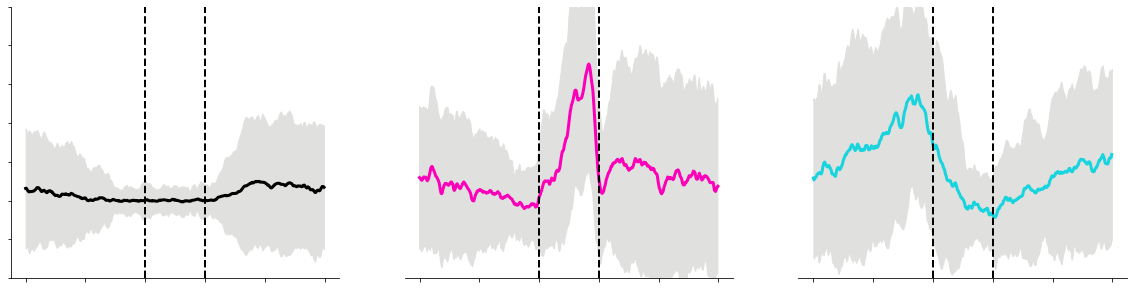

In [14]:
order=[ 'flat','inc', 'dec',]
fig,axs=plt.subplots(nrows=1,ncols=len(order),figsize=(20,5))
for i,be in enumerate(order):
    mean_trace=np.mean(total_trials[be]['trials'], axis=0)
    std_trace=np.std(total_trials[be]['trials'], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);
#     axs[i].set_xlim(150, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    if be!='flat':
        axs[i].spines['left'].set_visible(False)
        axs[i].set_yticks([])

In [15]:
print(behave_set.keys())
print(behave_set['227'].keys())
print(np.shape(behave_set['227']['labels']))
print(np.shape(behave_set['227']['event_times']))

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['timestamps', 'event_times', 'behavior', 'labels'])
(197,)
(197,)


In [16]:
# key=np.array(list(behave_set.keys()))[-1]
# labs=np.unique(behave_set[key]['labels'])
labs=['inc','dec','flat','non']
double_events={}
for fly in fly_nums:
    fly_name=str(fly)
    double_events[fly_name]={}
    for l in labs:
        for b in labs:
            double_events[fly_name][f'{l}_{b}']=[]

In [17]:
for fly in total_events:
    for behave in labs:
        events=total_events[fly][behave]
        for e in events:
            idx=int(np.where(behave_set[fly]['event_times']==e)[0])
            if idx!=0:
                prev=behave_set[fly]['labels'][idx-1]
                double_events[fly][f'{behave}_{prev}'].append(e)

In [18]:
print(double_events.keys())
print(double_events['250'].keys())
print(double_events['250']['inc_inc'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc_inc', 'inc_dec', 'inc_flat', 'inc_non', 'dec_inc', 'dec_dec', 'dec_flat', 'dec_non', 'flat_inc', 'flat_dec', 'flat_flat', 'flat_non', 'non_inc', 'non_dec', 'non_flat', 'non_non'])
[]


In [19]:
print(total_events.keys())
print(total_events['227'].keys())
print(total_events['227']['inc'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['total', 'inc', 'dec', 'flat', 'non'])
[]


In [20]:
# new_event_name='prev_behavior'
# event_list=double_events

# later_path = os.path.join(later_dir, f'{new_event_name}_event_times_split_dic.pkl')

# with open(later_path, 'wb') as file:
#     pickle.dump(event_list, file)

In [21]:
def rank_by_internal_variance(arr, axis=1):
    """
    Rank by the variance within each element (row).
    High internal variance = more spread in that row.
    """
    arr = np.array(arr)
    
    # Variance of each row
    row_variances = np.var(arr, axis=axis)
    
    # Sort by variance (descending)
    rankings = np.argsort(row_variances)[::-1]
    
    return rankings, row_variances

arr=np.asarray(total_trials['inc']['trials'])[:,150:200]
rankings, variances = rank_by_internal_variance(arr)
variances[rankings[70]]
# print("Top internal variance:")
# for i in range(70):
#     idx = rankings[i]
#     print(f"  Row {idx}: variance = {variances[idx]:.6f}")

0.084102332938604

In [22]:
arr.shape

(132, 50)

In [23]:
labs=['inc','inc_low','inc_lowest','flat']
subsamp_inc={}
for fly in fly_nums:
    fly_name=str(fly)
    subsamp_inc[fly_name]={}
    for l in labs:
        subsamp_inc[fly_name][l]=[]

In [24]:
low=[]
lowest=[]
for i,trial in enumerate(total_trials['inc']['trials']):
    fly_num=total_trials['inc']['fly'][i]
    event_num=total_trials['inc']['events'][i]
    trial_var=np.var(trial[150:200])
    if trial_var<variances[rankings[15]]:
        subsamp_inc[fly_num]['inc_low'].append(event_num)
        low.append(trial)
    if trial_var<variances[rankings[70]]:
        subsamp_inc[fly_num]['inc_lowest'].append(event_num)
        lowest.append(trial)
for fly in subsamp_inc:
    subsamp_inc[fly]['inc']=total_events[fly]['inc']
    subsamp_inc[fly]['flat']=total_events[fly]['flat']

(116, 500)


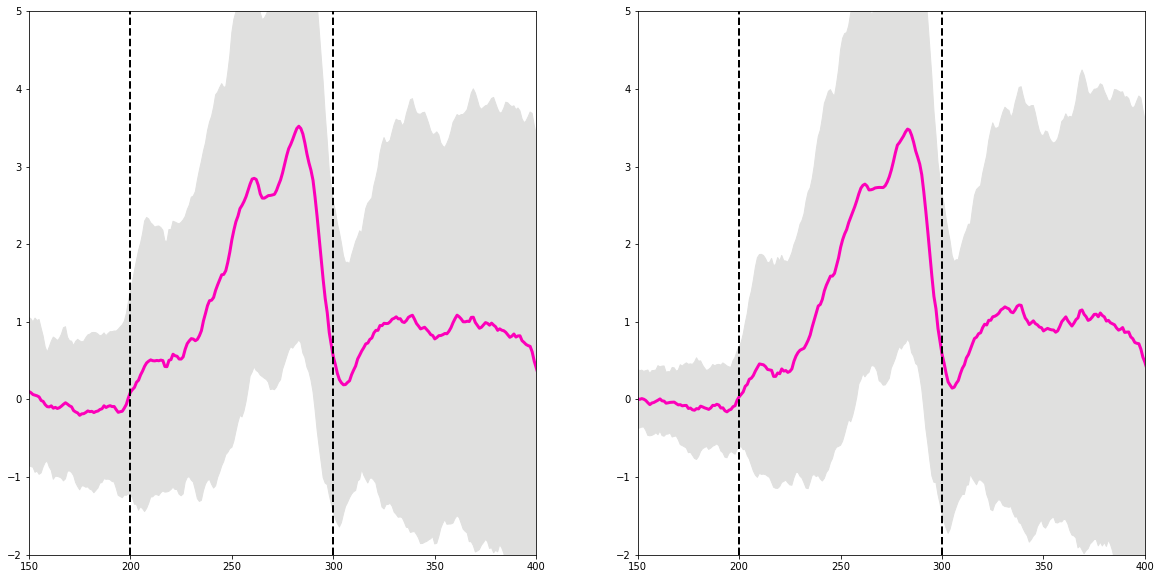

In [25]:
array=np.array(low)
be='inc'
print(array.shape)
fig,axs=plt.subplots(1,2,figsize=(20,10))
mean_trace=np.mean(total_trials[be]['trials'], axis=0)
std_trace=np.std(total_trials[be]['trials'], axis=0)
axs[0].plot(mean_trace, color=behavior_colors[be],lw=3)
axs[0].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[0].axvline(200, linewidth=2, linestyle='--', color='k')
axs[0].axvline(300, linewidth=2, linestyle='--', color='k')
axs[0].set_ylim(-2, 5);
axs[0].set_xlim(150, 400);
mean_trace=np.mean(array, axis=0)
std_trace=np.std(array, axis=0)
axs[1].plot(mean_trace, color=behavior_colors[be],lw=3)
axs[1].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[1].axvline(200, linewidth=2, linestyle='--', color='k')
axs[1].axvline(300, linewidth=2, linestyle='--', color='k')
axs[1].set_ylim(-2, 5);
axs[1].set_xlim(150, 400);

In [26]:
print(subsamp_inc.keys())
print(subsamp_inc['226'].keys())
print(subsamp_inc['226']['inc_lowest'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'inc_low', 'inc_lowest', 'flat'])
[1138180, 1178300, 1367220]


In [27]:
# new_event_name='subsamp_inc'
# event_list=subsamp_inc

# later_path = os.path.join(later_dir, f'{new_event_name}_event_times_split_dic.pkl')

# with open(later_path, 'wb') as file:
#     pickle.dump(event_list, file)

In [29]:
nineteen_events={}
behaviors=['total','non_neg', 'non_pos']
nineteen_trials={}
nineteen_pre_post={}
for b in behaviors:
    nineteen_trials[b]={'trials':[],'events':[],'fly':[]}
    nineteen_pre_post[b]=[] 

behave_set=all_behave_dict
for fly in behave_set:
    looms=behave_set[fly]['event_times']
    fly_Y=behave_set[fly]['behavior']['Y']
    nineteen_events[fly]={}
    for b in behaviors:
        nineteen_events[fly][b]=[]
    for i,trial in enumerate(fly_Y):
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        nineteen_trials['total']['trials'].append(fly_behavior['Y'][i])
        nineteen_trials['total']['events'].append(looms[i])
        nineteen_trials['total']['fly'].append(fly)
        nineteen_pre_post['total'].append([pre, post])
        nineteen_events[fly]['total'].append(looms[i])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1 or post>np.abs(pre*2) or post<pre/2:
            continue
        else:
            if pre<=0:
                nineteen_trials['non_neg']['trials'].append(fly_behavior['Y'][i])
                nineteen_trials['non_neg']['events'].append(looms[i])
                nineteen_trials['non_neg']['fly'].append(fly)
                nineteen_pre_post['non_neg'].append([pre, post, i])
                nineteen_events[fly]['non_neg'].append(looms[i])
            else:
                nineteen_trials['non_pos']['trials'].append(fly_behavior['Y'][i])
                nineteen_trials['non_pos']['events'].append(looms[i])
                nineteen_trials['non_pos']['fly'].append(fly)
                nineteen_pre_post['non_pos'].append([pre, post, i])
                nineteen_events[fly]['non_pos'].append(looms[i])

In [31]:
non_behavior_colors={
    'non_neg': '#2D3047',
    'non_pos': '#048A81',
    'total': '#F5F5F5'
}

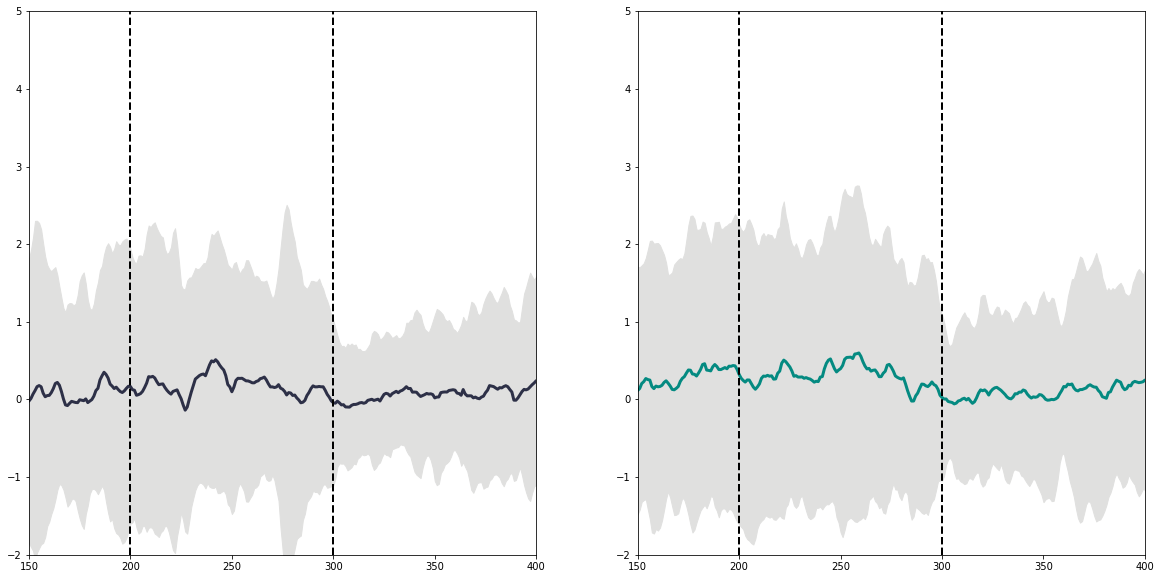

In [33]:
plot_dict=nineteen_trials
be='non_neg'
fig,axs=plt.subplots(1,2,figsize=(20,10))
mean_trace=np.mean(plot_dict[be]['trials'], axis=0)
std_trace=np.std(plot_dict[be]['trials'], axis=0)
axs[0].plot(mean_trace, color=non_behavior_colors[be],lw=3)
axs[0].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[0].axvline(200, linewidth=2, linestyle='--', color='k')
axs[0].axvline(300, linewidth=2, linestyle='--', color='k')
axs[0].set_ylim(-2, 5);
axs[0].set_xlim(150, 400);
be='non_pos'
mean_trace=np.mean(plot_dict[be]['trials'], axis=0)
std_trace=np.std(plot_dict[be]['trials'], axis=0)
axs[1].plot(mean_trace, color=non_behavior_colors[be],lw=3)
axs[1].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs[1].axvline(200, linewidth=2, linestyle='--', color='k')
axs[1].axvline(300, linewidth=2, linestyle='--', color='k')
axs[1].set_ylim(-2, 5);
axs[1].set_xlim(150, 400);

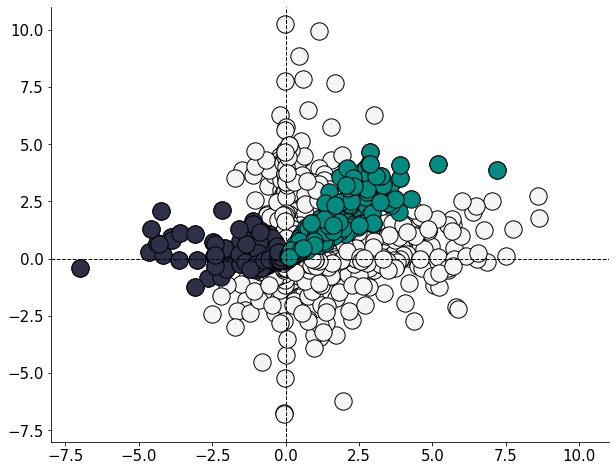

In [40]:
fig,ax=plt.subplots(figsize=(10, 8))
behavior_set=nineteen_pre_post
order=['total','non_neg','non_pos']
for key in order:
    ax.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=300,color=non_behavior_colors[key], edgecolor='k', label=key);
# behavior_set=pre_post
# order=['inc','dec','flat']
# for key in order:
#     ax.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=300,color=behavior_colors[key], edgecolor='k', label=key);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
# ax.set_xticklabels([]);
# ax.set_yticklabels([]);
ax.set_xlim(-8,11)
ax.set_ylim(-8,11)
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

In [45]:
for fly in nineteen_events:
    del nineteen_events[fly]['total']

In [47]:
print(nineteen_events.keys())
print(nineteen_events['227'].keys())
print(nineteen_events['227']['non_neg'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['non_neg', 'non_pos'])
[468270, 484680, 530720, 687930, 764670, 827050, 932230, 962660, 1063050, 1159470, 1262830, 1336210, 1492470, 1553900, 1680890, 1688180, 1694810, 1748860]


In [48]:
# new_event_name='nineteen_percent'
# event_list=nineteen_events

# later_path = os.path.join(later_dir, f'{new_event_name}_event_times_split_dic.pkl')

# with open(later_path, 'wb') as file:
#     pickle.dump(event_list, file)